In [20]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go
from scripts import FDD as fdd
from scipy.linalg import eig
from scipy.signal import welch, csd
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D


In [2]:
nodes = []
nodal_values = np.loadtxt('../text_files/nodes_minimal_model.txt', delimiter=',')
for i in range(nodal_values.shape[0]):
  nodes.append(n.nodes(nodal_values[i, 0], nodal_values[i, 1], nodal_values[i, 2]))

# **Primary truss parameters**

In [3]:
E = 210e9  # Young's modulus in Pascals
nu = 0.3   # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus in Pascals
m = 6.7504 * 10 ** 6 #kg
m = 5596024
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.03 #m
t2 = 0.08 #m
L_truss_element_y = 15 #m
h_truss = 18 #m
Aeq, Ieqy, Ieqz, b_eq, h_eq = mat.effective_truss_stiffness(d1, d2, t1, t2, h_truss, L_truss_element_y) 
L = 237.5
rho_truss = m / (L * Aeq)
It = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
k = 0.08
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho_truss, Aeq, Ieqy, Ieqz, Ip]

# **Fenders, connecting elements and retaining wall parameters**

In [4]:
k = 5/6
rho = 7850 #kg/m^3
E=210e9 #Pa
G = E/(2*(1+nu)) #Pa
nu = 0.3 #Poisson's ratio
k_fender =  mat.stiffness_fenders()
Iy_connect, Iz_connect, Ip_connect, It_connect, A_connect = mat.stiffness_connecting_beams()
ep_K_connect = [E, G, A_connect, Iy_connect, Iz_connect, It_connect, k]
ep_m_connect = [rho, A_connect, Iy_connect, Iz_connect, Ip_connect]

h_eq = 22
Iy_wall = 1250
Iz_wall = 0.25 * Iy_wall
Ip_wall = Iy_wall + Iz_wall
It_wall = 0.05 * Iy_wall
A_wall = Iy_wall * 12 / h_eq**2
m_wall = 6455148
L_wall = 237.5
rho_wall = m_wall / (L_wall * A_wall)
ep_K_wall = [E, G, A_wall, Iy_wall, Iz_wall, It_wall, k]
ep_m_wall = [rho_wall, A_wall, Iy_wall, Iz_wall, Ip_wall]


# **Connecting truss parameters**

In [5]:

A_eq, Iy_eq, Iz_eq, b_eq, h_eq = mat.stiffness_connecting_truss(d1, d2, t1, t2, h_truss, L_truss_element_y)
Ip_connecting_truss = Iy_eq + Iz_eq 
It_eq = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
ep_K_connecting_truss = [E, G, A_eq, Iy_eq, Iz_eq, It_eq, k]
ep_m_connecting_truss = [rho_truss, A_eq, Iy_eq, Iz_eq, Ip_connect]

# **Braces parameters**

In [ ]:
k = 5/6
Iy, Iz, Ip, It, A = mat.stiffness_braces()
ep_K_braces = [E, G, A, Iy, Iz, It, k]
ep_m_braces = [rho, A, Iy, Iz, Ip]

# **Assembling the material properties to the correct elements**

In [7]:
elements = []
element_nodes = np.loadtxt('../text_files/element_nodes.txt', dtype=int)
for i in range(element_nodes.shape[0]):
    if element_nodes[i, 2] == 0:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K, ep_m))
    elif element_nodes[i, 2] == 1:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_wall, ep_m_wall))
    elif element_nodes[i, 2] == 2:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connect, ep_m_connect))
    elif element_nodes[i, 2] == 3:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connecting_truss, ep_m_connecting_truss))   
    elif element_nodes[i, 2] == 4:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_braces, ep_m_braces))
element_nodes = element_nodes[:, :2] # Remove the column with element type information


dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))

# **Assemble global mass and stiffness matrix**

In [ ]:
N = len(nodes)
DOFS_per_node = 6



K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
print(K_global.shape    )

K_locs = []
M_locs = []



for i in range(len(element_locs)):
    K_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-1]
    M_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-2]



# To restore symmetry of the global stiffness and mass matrices
K_global = 0.5 * (K_global + K_global.T)
M_global = 0.5 * (M_global + M_global.T)

(1086, 1086)


In [9]:
fender_dofs = [70, 75, 79, 83, 87, 91, 95, 99, 103, 107, 111, 115, 119, 123, 128]

k_fender_dofs = [dofs[f'dof_{i+1}'][2] for i in fender_dofs]
for dof in k_fender_dofs:
    K_global[dof, dof] += k_fender

In [10]:
indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_75'][0:2]))
keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]

In [11]:
eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)


tol = 1e-6
positive = eigvals_global > tol
eigvals_global = eigvals_global[positive]
eigvecs_global = eigvecs_global[:, positive]

frequencies_rad = np.sqrt(eigvals_global)
frequencies_hz = frequencies_rad / (2 * np.pi)


data_freqs = pd.DataFrame({
    'Frequency (Hz)': frequencies_hz,
    'Frequency (rad/s)': frequencies_rad
})

display(data_freqs[:15])


,Frequency (Hz),Frequency (rad/s)
0,0.498646,3.133086
1,0.647765,4.070027
2,1.506127,9.463274
3,1.523845,9.574600
4,1.612083,10.129018
5,1.896094,11.913512
6,2.165500,13.606240
7,2.301791,14.462579
8,2.555512,16.056755
9,3.339235,20.981030


In [ ]:
eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_indices, N*DOFS_per_node)


Expanded eigenvectors shape: (1081, 1081)


In [13]:
eigvecs_disp_full = e.extract_displacement(eigvecs_full, keep=3, skip=3)
eigvecs_full.shape

(1086, 1081)

## **Damping Matrix**

In [14]:
zeta =  0.02
C_star = np.diag(2 * zeta * frequencies_rad)
C_global_reduced = M_global_reduced @ eigvecs_global @ C_star @ eigvecs_global.T @ M_global_reduced


In [15]:
n = K_global_reduced.shape[0]


Z = np.zeros((n, n))
I = np.eye(n)

A = np.block([[Z, I],
              [-K_global_reduced, -C_global_reduced]])

B = np.block([[I, Z],
              [Z, M_global_reduced]])

eigvals, eigvecs = eig(A, B)
eigvals = np.array(eigvals)
idx = np.argsort(np.imag(eigvals))
eigvals_sorted = eigvals[idx]

print(eigvals_sorted)


[-257.75591809-12885.21808593j -253.21350299-12658.14338779j
 -252.10464883-12602.71055142j ... -252.10464883+12602.71055142j
 -253.21350299+12658.14338779j -257.75591809+12885.21808593j]


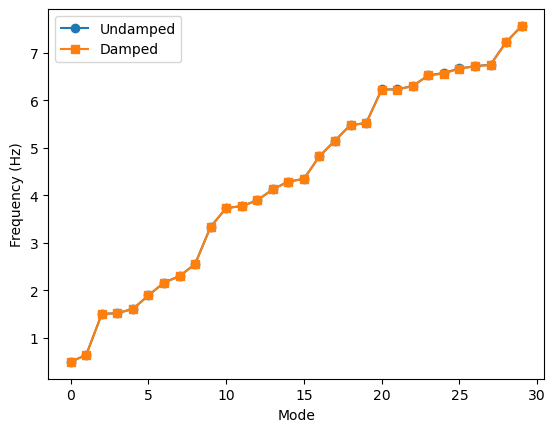

In [16]:
phys = eigvals_sorted[np.imag(eigvals_sorted) > 0]
omega_d = np.imag(phys)
f_hz_d = omega_d / (2 * np.pi)
f_hz_d

plt.plot(frequencies_hz[:30], 'o-', label='Undamped')
plt.plot(f_hz_d[:30], 's-', label='Damped')
plt.xlabel('Mode')
plt.ylabel('Frequency (Hz)')
plt.legend()
plt.show()

In [17]:
display(data_freqs[:15])

,Frequency (Hz),Frequency (rad/s)
0,0.498646,3.133086
1,0.647765,4.070027
2,1.506127,9.463274
3,1.523845,9.574600
4,1.612083,10.129018
5,1.896094,11.913512
6,2.165500,13.606240
7,2.301791,14.462579
8,2.555512,16.056755
9,3.339235,20.981030


## **Applying Frequency Domain Decomposition on 12 sensors**

In [19]:

dt = 0.01
T = 1000
t = np.arange(0, T, dt)
n_steps = len(t)

# Matrices must already exist:
M = M_global_reduced
C = C_global_reduced
K = K_global_reduced
n_dof = M.shape[0]


np.random.seed(1)
f_white = np.random.randn(n_steps, n_dof)


def newmark_beta(M, C, K, f, dt, beta=1/4, gamma=1/2):

    n_steps, n_dof = f.shape
    u = np.zeros((n_steps, n_dof))
    v = np.zeros((n_steps, n_dof))
    a = np.zeros((n_steps, n_dof))

    # initial acceleration
    a[0] = np.linalg.solve(M, f[0] - C @ v[0] - K @ u[0])

    # effective stiffness
    K_eff = K + gamma/(beta*dt)*C + M/(beta*dt**2)
    K_eff_inv = np.linalg.inv(K_eff)

    for i in range(1, n_steps):

        rhs = (
            f[i]
            + M @ (u[i-1]/(beta*dt**2) + v[i-1]/(beta*dt) + (1/(2*beta)-1)*a[i-1])
            + C @ (gamma/(beta*dt)*u[i-1] + (gamma/beta-1)*v[i-1] + dt*(gamma/(2*beta)-1)*a[i-1])
        )

        u[i] = K_eff_inv @ rhs
        v[i] = gamma/(beta*dt)*(u[i] - u[i-1]) + (1 - gamma/beta)*v[i-1] + dt*(1 - gamma/(2*beta))*a[i-1]
        a[i] = (u[i] - u[i-1])/(beta*dt**2) - v[i-1]/(beta*dt) - (1/(2*beta)-1)*a[i-1]

    return u, v, a


u, v, acc = newmark_beta(M, C, K, f_white, dt)


selected_dofs = []
node_numbers = [1, 2, 3, 4, 12, 19, 31, 38, 70, 78, 94, 113]
for i in range(len(node_numbers)):
    if node_numbers[i] <76:
        selected_dofs.extend([node_numbers[i]*6-3 + j for j in range(3)])
    else:
        selected_dofs.extend([node_numbers[i]*6-3-2+j for j in range(3)])
Y = u[:, selected_dofs]  
m = Y.shape[1]           


fs = 1/dt
nperseg = 8192

# Frequency vector
f, _ = welch(Y[:, 0], fs=fs, nperseg=nperseg)
n_freqs = len(f)

# PSD matrix S(f) → shape: [freq, m, m]
S = np.zeros((n_freqs, m, m), dtype=complex)

for i in range(m):
    for j in range(m):
        _, Pij = csd(Y[:, i], Y[:, j], fs=fs, nperseg=nperseg)
        S[:, i, j] = Pij


U_svd = np.zeros((n_freqs, m, m), dtype=complex)
Svals = np.zeros((n_freqs, m))

for k in range(n_freqs):
    U_k, s_k, _ = np.linalg.svd(S[k])
    U_svd[k] = U_k
    Svals[k] = s_k


num_modes_to_plot = min(10, m)

colors = [
    "firebrick", "royalblue", "green", "orange", "purple",
    "brown", "pink", "grey", "yellow", "black"
]

fig = go.Figure()

for i in range(num_modes_to_plot):
    fig.add_trace(go.Scatter(
        x=f,
        y=Svals[:, i],
        name=f"Singular value {i+1}",
        line=dict(color=colors[i], width=2)
    ))

fig.update_yaxes(type="log")

fig.update_layout(
    xaxis=dict(title="Frequency [Hz]"),
    yaxis=dict(title="Singular values"),
    showlegend=False,
    title="FDD Singular Value Spectrum (First 10 SVD Values)"
)

fig.show()


k_peak = np.argmax(Svals[:, 0])
mode_shape = U_svd[k_peak, :, 0]

print("Peak frequency =", f[k_peak], "Hz")
print("\nMode shape (normalized):")
print(mode_shape / np.max(np.abs(mode_shape)))

Peak frequency = 0.50048828125 Hz

Mode shape (normalized):
[-2.84002366e-05-2.11022065e-21j  1.16234164e-04+3.20937964e-06j
  2.59685702e-02+8.76823729e-01j -3.13312854e-05+1.14025965e-05j
  4.58956739e-04+2.33235782e-04j -1.54286276e-03+6.01323409e-01j
  2.04683574e-04+2.53849840e-04j  3.83134483e-04+1.92175076e-04j
 -1.25354002e-03+5.30208158e-01j  2.48322302e-04+2.28860744e-04j
  1.53074369e-04+4.41959667e-05j  2.14984857e-02+7.59549429e-01j
  1.69031557e-03-1.59771841e-04j  3.88718269e-04-5.48881094e-05j
  9.88008334e-03+3.63358903e-01j  1.26893646e-03+4.98522181e-04j
  3.29057181e-04+8.22312869e-05j  1.70857249e-02+6.23444870e-01j
  1.27714676e-03-5.50273080e-04j -7.58661181e-05+2.03566787e-04j
 -1.02381228e-03+2.58191894e-01j  1.09338936e-03-1.13426339e-04j
  1.06881866e-04+2.01010209e-04j -1.55504868e-03+4.39541143e-01j
  1.36379881e-05-2.00279223e-06j -3.21379991e-05+3.93482786e-06j
  4.17714965e-02+9.99127190e-01j -9.34506972e-06+2.52123387e-06j
  3.07535833e-05-7.60374207e-0

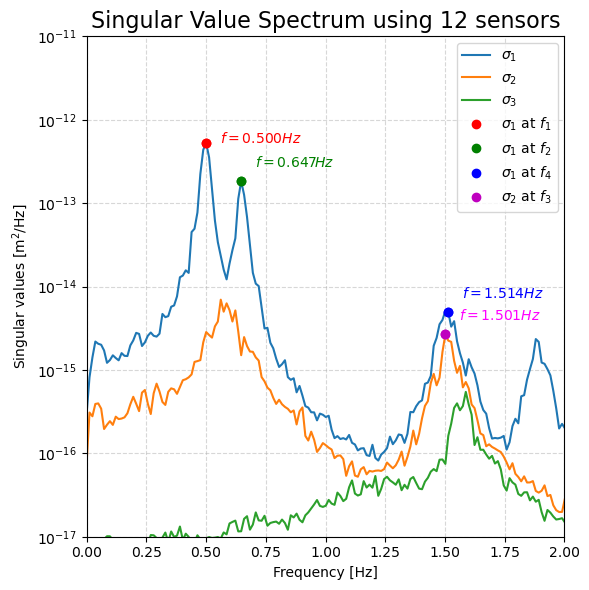

In [21]:
num_modes_to_plot = min(3, m)

plt.figure(figsize=(6, 6))

for i in range(num_modes_to_plot):
    plt.plot(f, Svals[:, i], label=f'$\\sigma_{{{i+1}}}$')

plt.xlim(0, 2)
plt.yscale('log')

plt.xlabel("Frequency [Hz]")
plt.ylabel("Singular values [m$^2$/Hz]")
plt.title("Singular Value Spectrum using 12 sensors", fontsize=16)

plt.plot(f[41], Svals[41, 0], 'ro', label='$\sigma_1$ at $f_1$')
plt.plot(f[53], Svals[53, 0], 'go', label='$\sigma_1$ at $f_2$')
plt.plot(f[124], Svals[124, 0], 'bo', label='$\sigma_1$ at $f_4$')
plt.plot(f[123], Svals[123, 1], 'mo', label='$\sigma_2$ at $f_3$')

ax = plt.gca()

ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_minor_locator(mticker.NullLocator())

plt.plot(f[41], Svals[41, 0], 'ro')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[41]), xy=(f[41], Svals[41, 0]),
             xytext=(10, 0), textcoords='offset points',
             color='red')

plt.plot(f[53], Svals[53, 0], 'go')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[53]), xy=(f[53], Svals[53, 0]),
             xytext=(10, 10), textcoords='offset points',
             color='green')

plt.plot(f[124], Svals[124, 0], 'bo')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[124]), xy=(f[124], Svals[124, 0]),
             xytext=(10, 10), textcoords='offset points',
             color='blue')

plt.plot(f[123], Svals[123, 1], 'mo')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[123]), xy=(f[123], Svals[123, 1]),
             xytext=(10, 10), textcoords='offset points',
             color='magenta')

plt.grid(True, which='major', linestyle='--', alpha=0.5)

# Legend outside
plt.legend(loc='upper right')


plt.tight_layout()
plt.ylim(1e-17, 1e-11)
plt.show()



Natural frequency f_1 = 0.4986 Hz -> index 41
Natural frequency f_2 = 0.6478 Hz -> index 53
Natural frequency f_3 = 1.5061 Hz -> index 123
Natural frequency f_4 = 1.5238 Hz -> index 125
36
4


c:\Users\alami\Desktop\MSc-thesis----Minimal-model----Maeslantkering\scripts\FDD.py:118: ComplexWarning:

Casting complex values to real discards the imaginary part



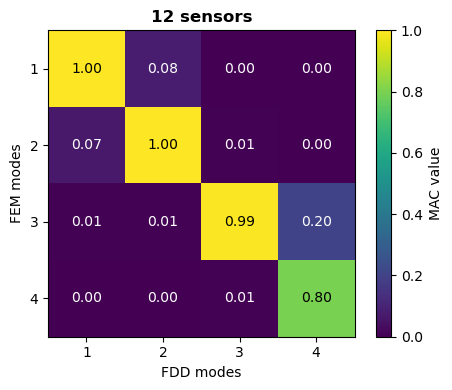

In [23]:
# Obtaining correct index corresponding to natural frequencies in the FDD plot to extract mode shapes.

phi_experiment = []

for i in range(4):
    idx = np.argmin(np.abs(f - frequencies_hz[i]))
    print(f"Natural frequency f_{i+1} = {frequencies_hz[i]:.4f} Hz -> index {idx}")

    mode = U_svd[idx, :, 0]

    # ---- Phase normalization (correct way) ----
    ref = np.argmax(np.abs(mode))
    mode = mode * np.exp(-1j * np.angle(mode[ref]))

    # ---- Normalize magnitude ----
    mode = mode / np.max(np.abs(mode))

    phi_experiment.append(mode)

phi_experiment = np.array(phi_experiment).T   # shape: (channels, modes)

# Reducing the model mode shapes to the DOFS corresponding to the experimental measurements for comparison.
eigvecs_reduced = eigvecs_global[selected_dofs, :4] 


print(len(eigvecs_reduced[:, 0])) 
print(len(phi_experiment[0])) 
fdd.plot_mac(fdd.compute_mac(eigvecs_reduced, phi_experiment), '12 sensors', xlabel='FDD modes', ylabel='FEM modes')
np.save('experimental_eigvectors/phi_experiment_12_sensors.npy', phi_experiment)


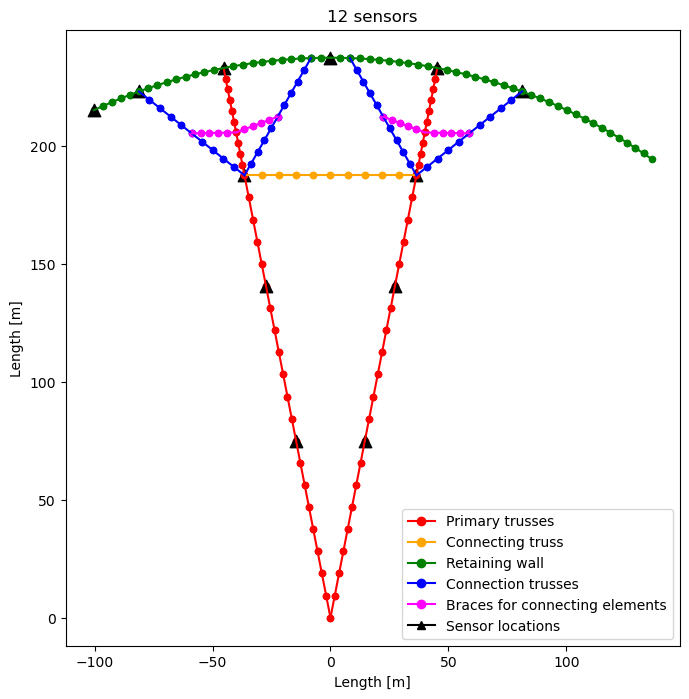

In [24]:

def plot_elements2d(elements):

    fig, ax = plt.subplots(figsize=(8, 8))

    for i, element in enumerate(elements):
        n1, n2, _, _ = element
        x = [n1[0], n2[0]]
        y = [n1[1], n2[1]]

        if i < 60:
            color = 'red'
        elif i < 70:
            color = 'orange'
        elif i < 130:
            color = 'green'
        elif i < 169:
            color = 'blue'
        elif i > 169:
            color = 'magenta'
        # Plot line
        ax.plot(x, y, color=color)

        # Plot nodes
        ax.scatter(*n1[:2], color=color, s=20)
        ax.scatter(*n2[:2], color=color, s=20)
    
    for i, element in enumerate(elements):
        n1, n2, _, _ = element
        x = [n1[0], n2[0]]
        y = [n1[1], n2[1]]

        if i == 130 or i == 140 or i == 150 or i == 160:
            color = 'red'
            ax.scatter(*n1[:2], color=color, s=20)

        elif i == 139 or i == 149 or i == 159 or i == 169:
            color = 'green'
            ax.scatter(*n2[:2], color=color, s=20)
        elif i == 170 or i == 185:
            color = 'red'
            ax.scatter(*n1[:2], color=color, s=20)


    
    # for i, element in enumerate(elements):
        if i == 29 or i == 49 or i == 59 or i == 60 or i == 8 or i == 15 or i == 38 or i == 45 or i == 70 or i == 75 or i == 95 or i == 115:
            color = 'black'
            ax.scatter(*n1[:2], color=color, s=80, marker='^')
  




    # ---- Custom legend: line + ball marker ----
    legend_handles = [
        Line2D([0], [0], color='red', marker='o', markersize=6, label='Primary trusses'),
        Line2D([0], [0], color='orange', marker='o', markersize=6, label='Connecting truss'),
        Line2D([0], [0], color='green', marker='o', markersize=6, label='Retaining wall'),
        Line2D([0], [0], color='blue', marker='o', markersize=6, 
               label='Connection trusses'),
        Line2D([0], [0], color='magenta', marker='o', markersize=6, label='Braces for connecting elements'), 
        Line2D([0], [0], color='black', marker='^', markersize=6, label='Sensor locations')

    ]

    ax.legend(handles=legend_handles, loc='lower right')

    ax.set_xlabel('Length [m]')
    ax.set_ylabel('Length [m]')
    ax.set_aspect('equal')
    ax.set_title('12 sensors')
    plt.show()

plot_elements2d(elements)

## **Applying Frequency Domain Decomposition on 2 sensors**

In [25]:
dt = 0.01
T = 1000
t = np.arange(0, T, dt)
n_steps = len(t)

# Matrices must already exist:
M = M_global_reduced
C = C_global_reduced
K = K_global_reduced
n_dof = M.shape[0]


np.random.seed(1)
f_white = np.random.randn(n_steps, n_dof)


def newmark_beta(M, C, K, f, dt, beta=1/4, gamma=1/2):

    n_steps, n_dof = f.shape
    u = np.zeros((n_steps, n_dof))
    v = np.zeros((n_steps, n_dof))
    a = np.zeros((n_steps, n_dof))

    # initial acceleration
    a[0] = np.linalg.solve(M, f[0] - C @ v[0] - K @ u[0])

    # effective stiffness
    K_eff = K + gamma/(beta*dt)*C + M/(beta*dt**2)
    K_eff_inv = np.linalg.inv(K_eff)

    for i in range(1, n_steps):

        rhs = (
            f[i]
            + M @ (u[i-1]/(beta*dt**2) + v[i-1]/(beta*dt) + (1/(2*beta)-1)*a[i-1])
            + C @ (gamma/(beta*dt)*u[i-1] + (gamma/beta-1)*v[i-1] + dt*(gamma/(2*beta)-1)*a[i-1])
        )

        u[i] = K_eff_inv @ rhs
        v[i] = gamma/(beta*dt)*(u[i] - u[i-1]) + (1 - gamma/beta)*v[i-1] + dt*(1 - gamma/(2*beta))*a[i-1]
        a[i] = (u[i] - u[i-1])/(beta*dt**2) - v[i-1]/(beta*dt) - (1/(2*beta)-1)*a[i-1]

    return u, v, a


u, v, acc = newmark_beta(M, C, K, f_white, dt)



node_numbers = [1, 38]
selected_dofs = [node*6-3 + i for node in node_numbers for i in range(3)] 
Y = u[:, selected_dofs]  
m = Y.shape[1]           


fs = 1/dt
nperseg = 8192

# Frequency vector
f, _ = welch(Y[:, 0], fs=fs, nperseg=nperseg)
n_freqs = len(f)

# PSD matrix S(f) → shape: [freq, m, m]
S = np.zeros((n_freqs, m, m), dtype=complex)

for i in range(m):
    for j in range(m):
        _, Pij = csd(Y[:, i], Y[:, j], fs=fs, nperseg=nperseg)
        S[:, i, j] = Pij

U_svd = np.zeros((n_freqs, m, m), dtype=complex)
Svals = np.zeros((n_freqs, m))

for k in range(n_freqs):
    U_k, s_k, _ = np.linalg.svd(S[k])
    U_svd[k] = U_k
    Svals[k] = s_k


num_modes_to_plot = min(10, m)

colors = [
    "firebrick", "royalblue", "green", "orange", "purple",
    "brown", "pink", "grey", "yellow", "black"
]

fig = go.Figure()

for i in range(num_modes_to_plot):
    fig.add_trace(go.Scatter(
        x=f,
        y=Svals[:, i],
        name=f"Singular value {i+1}",
        line=dict(color=colors[i], width=2)
    ))

fig.update_yaxes(type="log")

fig.update_layout(
    xaxis=dict(title="Frequency [Hz]"),
    yaxis=dict(title="Singular values"),
    showlegend=False,
    title="FDD Singular Value Spectrum (First 10 SVD Values)"
)

fig.show()

k_peak = np.argmax(Svals[:, 0])
mode_shape = U_svd[k_peak, :, 0]

print("Peak frequency =", f[k_peak], "Hz")
print("\nMode shape (normalized):")
print(mode_shape / np.max(np.abs(mode_shape)))

Peak frequency = 0.50048828125 Hz

Mode shape (normalized):
[-3.23574271e-05-5.82774742e-18j  1.32422173e-04+3.54379787e-06j
  3.23718782e-02+9.99475893e-01j  1.25336070e-03-1.31140532e-04j
  1.22028505e-04+2.28710797e-04j -3.53668842e-04+5.01210534e-01j]


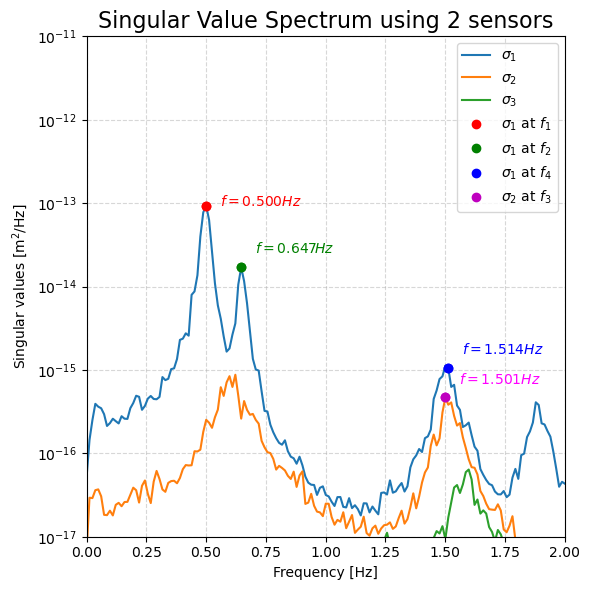

In [26]:
num_modes_to_plot = min(3, m)

plt.figure(figsize=(6, 6))

for i in range(num_modes_to_plot):
    plt.plot(f, Svals[:, i], label=f'$\\sigma_{{{i+1}}}$')

plt.xlim(0, 2)
plt.yscale('log')

plt.xlabel("Frequency [Hz]")
plt.ylabel("Singular values [m$^2$/Hz]")
plt.title("Singular Value Spectrum using 2 sensors", fontsize=16)

plt.plot(f[41], Svals[41, 0], 'ro', label='$\sigma_1$ at $f_1$')
plt.plot(f[53], Svals[53, 0], 'go', label='$\sigma_1$ at $f_2$')
plt.plot(f[124], Svals[124, 0], 'bo', label='$\sigma_1$ at $f_4$')
plt.plot(f[123], Svals[123, 1], 'mo', label='$\sigma_2$ at $f_3$')
ax = plt.gca()

ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_minor_locator(mticker.NullLocator())

plt.plot(f[41], Svals[41, 0], 'ro')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[41]), xy=(f[41], Svals[41, 0]),
             xytext=(10, 0), textcoords='offset points',
             color='red')

plt.plot(f[53], Svals[53, 0], 'go')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[53]), xy=(f[53], Svals[53, 0]),
             xytext=(10, 10), textcoords='offset points',
             color='green')

plt.plot(f[124], Svals[124, 0], 'bo')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[124]), xy=(f[124], Svals[124, 0]),
             xytext=(10, 10), textcoords='offset points',
             color='blue')

plt.plot(f[123], Svals[123, 1], 'mo')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[123]), xy=(f[123], Svals[123, 1]),
             xytext=(10, 10), textcoords='offset points',
             color='magenta')

plt.grid(True, which='major', linestyle='--', alpha=0.5)

# Legend outside
plt.legend(loc='upper right')
  

plt.tight_layout()
plt.ylim(1e-17, 1e-11)
plt.show()

Natural frequency f_1 = 0.4986 Hz -> index 41
Natural frequency f_2 = 0.6478 Hz -> index 53
Natural frequency f_3 = 1.5061 Hz -> index 123
Natural frequency f_4 = 1.5238 Hz -> index 125
6
4


c:\Users\alami\Desktop\MSc-thesis----Minimal-model----Maeslantkering\scripts\FDD.py:118: ComplexWarning:

Casting complex values to real discards the imaginary part



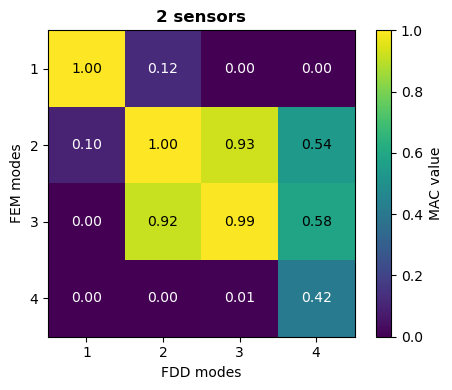

In [27]:
# Obtaining correct index corresponding to natural frequencies in the FDD plot to extract mode shapes.

phi_experiment = []

for i in range(4):
    idx = np.argmin(np.abs(f - frequencies_hz[i]))
    print(f"Natural frequency f_{i+1} = {frequencies_hz[i]:.4f} Hz -> index {idx}")

    mode = U_svd[idx, :, 0]

    # ---- Phase normalization (correct way) ----
    ref = np.argmax(np.abs(mode))
    mode = mode * np.exp(-1j * np.angle(mode[ref]))

    # ---- Normalize magnitude ----
    mode = mode / np.max(np.abs(mode))

    phi_experiment.append(mode)

phi_experiment = np.array(phi_experiment).T   # shape: (channels, modes)

# Reducing the model mode shapes to the DOFS corresponding to the experimental measurements for comparison.
eigvecs_reduced = eigvecs_global[selected_dofs, :4] 


print(len(eigvecs_reduced[:, 0])) 
print(len(phi_experiment[0])) 
fdd.plot_mac(fdd.compute_mac(eigvecs_reduced, phi_experiment), '2 sensors', xlabel='FDD modes', ylabel='FEM modes')
np.save('experimental_eigvectors/phi_experiment_2_sensors.npy', phi_experiment)


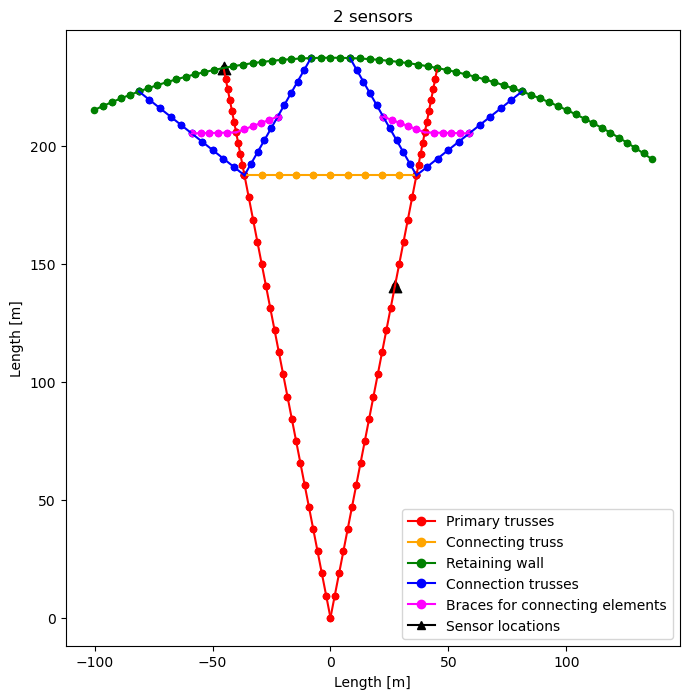

In [28]:
from matplotlib.lines import Line2D

def plot_elements2d(elements):

    fig, ax = plt.subplots(figsize=(8, 8))

    for i, element in enumerate(elements):
        n1, n2, _, _ = element
        x = [n1[0], n2[0]]
        y = [n1[1], n2[1]]

        if i < 60:
            color = 'red'
        elif i < 70:
            color = 'orange'
        elif i < 130:
            color = 'green'
        elif i < 169:
            color = 'blue'
        elif i > 169:
            color = 'magenta'
        # Plot line
        ax.plot(x, y, color=color)

        # Plot nodes
        ax.scatter(*n1[:2], color=color, s=20)
        ax.scatter(*n2[:2], color=color, s=20)
    
    for i, element in enumerate(elements):
        n1, n2, _, _ = element
        x = [n1[0], n2[0]]
        y = [n1[1], n2[1]]

        if i == 130 or i == 140 or i == 150 or i == 160:
            color = 'red'
            ax.scatter(*n1[:2], color=color, s=20)

        elif i == 139 or i == 149 or i == 159 or i == 169:
            color = 'green'
            ax.scatter(*n2[:2], color=color, s=20)
        elif i == 170 or i == 185:
            color = 'red'
            ax.scatter(*n1[:2], color=color, s=20)


    
    # for i, element in enumerate(elements):
        if i == 29 or i == 45:
            color = 'black'
            ax.scatter(*n1[:2], color=color, s=80, marker='^')
  




    # ---- Custom legend: line + ball marker ----
    legend_handles = [
        Line2D([0], [0], color='red', marker='o', markersize=6, label='Primary trusses'),
        Line2D([0], [0], color='orange', marker='o', markersize=6, label='Connecting truss'),
        Line2D([0], [0], color='green', marker='o', markersize=6, label='Retaining wall'),
        Line2D([0], [0], color='blue', marker='o', markersize=6, 
               label='Connection trusses'),
        Line2D([0], [0], color='magenta', marker='o', markersize=6, label='Braces for connecting elements'), 
        Line2D([0], [0], color='black', marker='^', markersize=6, label='Sensor locations')

    ]

    ax.legend(handles=legend_handles, loc='lower right')

    ax.set_xlabel('Length [m]')
    ax.set_ylabel('Length [m]')
    ax.set_aspect('equal')
    ax.set_title('2 sensors')
    plt.show()

plot_elements2d(elements)

## **Applying Frequency Domain Decomposition on 22 sensors**

In [29]:

dt = 0.01
T = 1000
t = np.arange(0, T, dt)
n_steps = len(t)

# Matrices must already exist:
M = M_global_reduced
C = C_global_reduced
K = K_global_reduced
n_dof = M.shape[0]



np.random.seed(1)
f_white = np.random.randn(n_steps, n_dof)


def newmark_beta(M, C, K, f, dt, beta=1/4, gamma=1/2):

    n_steps, n_dof = f.shape
    u = np.zeros((n_steps, n_dof))
    v = np.zeros((n_steps, n_dof))
    a = np.zeros((n_steps, n_dof))

    # initial acceleration
    a[0] = np.linalg.solve(M, f[0] - C @ v[0] - K @ u[0])

    # effective stiffness
    K_eff = K + gamma/(beta*dt)*C + M/(beta*dt**2)
    K_eff_inv = np.linalg.inv(K_eff)

    for i in range(1, n_steps):

        rhs = (
            f[i]
            + M @ (u[i-1]/(beta*dt**2) + v[i-1]/(beta*dt) + (1/(2*beta)-1)*a[i-1])
            + C @ (gamma/(beta*dt)*u[i-1] + (gamma/beta-1)*v[i-1] + dt*(gamma/(2*beta)-1)*a[i-1])
        )

        u[i] = K_eff_inv @ rhs
        v[i] = gamma/(beta*dt)*(u[i] - u[i-1]) + (1 - gamma/beta)*v[i-1] + dt*(1 - gamma/(2*beta))*a[i-1]
        a[i] = (u[i] - u[i-1])/(beta*dt**2) - v[i-1]/(beta*dt) - (1/(2*beta)-1)*a[i-1]

    return u, v, a

u, v, acc = newmark_beta(M, C, K, f_white, dt)


selected_dofs = []
node_numbers = [1, 2, 3, 4, 8, 12, 16, 19, 21, 27, 31, 35 , 
                38, 40, 46, 49, 55, 58, 70, 75, 94, 113]
for i in range(len(node_numbers)):
    if node_numbers[i] <75:
        selected_dofs.extend([node_numbers[i]*6-3 + j for j in range(3)])
    else:
        selected_dofs.extend([node_numbers[i]*6-3-2+j for j in range(3)])
Y = u[:, selected_dofs]  
m = Y.shape[1]           


fs = 1/dt
nperseg = 8192

# Frequency vector
f, _ = welch(Y[:, 0], fs=fs, nperseg=nperseg)
n_freqs = len(f)

# PSD matrix S(f) → shape: [freq, m, m]
S = np.zeros((n_freqs, m, m), dtype=complex)

for i in range(m):
    for j in range(m):
        _, Pij = csd(Y[:, i], Y[:, j], fs=fs, nperseg=nperseg)
        S[:, i, j] = Pij


U_svd = np.zeros((n_freqs, m, m), dtype=complex)
Svals = np.zeros((n_freqs, m))

for k in range(n_freqs):
    U_k, s_k, _ = np.linalg.svd(S[k])
    U_svd[k] = U_k
    Svals[k] = s_k


num_modes_to_plot = min(10, m)

colors = [
    "firebrick", "royalblue", "green", "orange", "purple",
    "brown", "pink", "grey", "yellow", "black"
]

fig = go.Figure()

for i in range(num_modes_to_plot):
    fig.add_trace(go.Scatter(
        x=f,
        y=Svals[:, i],
        name=f"Singular value {i+1}",
        line=dict(color=colors[i], width=2)
    ))

fig.update_yaxes(type="log")

fig.update_layout(
    xaxis=dict(title="Frequency [Hz]"),
    yaxis=dict(title="Singular values"),
    showlegend=False,
    title="FDD Singular Value Spectrum (First 10 SVD Values)"
)

fig.show()
k_peak = np.argmax(Svals[:, 0])
mode_shape = U_svd[k_peak, :, 0]

print("Peak frequency =", f[k_peak], "Hz")
print("\nMode shape (normalized):")
print(mode_shape / np.max(np.abs(mode_shape)))

Peak frequency = 0.50048828125 Hz

Mode shape (normalized):
[-2.83343540e-05+1.15034605e-18j  1.15935640e-04+3.18736713e-06j
  2.28048495e-02+8.77173492e-01j -3.12496272e-05+1.13547994e-05j
  4.59574900e-04+2.34916344e-04j -3.69759856e-03+6.01956892e-01j
  2.05458032e-04+2.54915188e-04j  3.83536252e-04+1.93579941e-04j
 -3.15592815e-03+5.30757499e-01j  2.48782836e-04+2.30097516e-04j
  1.52884252e-04+4.42786112e-05j  1.87551760e-02+7.59858689e-01j
  1.07565892e-03-2.90335834e-04j  2.44191301e-04-6.70389029e-05j
  4.28325897e-03+1.86886823e-01j  1.69177002e-03-1.40547546e-04j
  3.89021245e-04-5.11988539e-05j  8.56323797e-03+3.63505868e-01j
  1.66012501e-03+2.50872334e-04j  3.95846542e-04+2.65712001e-05j
  1.23231018e-02+5.21416780e-01j  1.26983330e-03+5.11776697e-04j
  3.29125839e-04+8.46017396e-05j  1.48316852e-02+6.23698941e-01j
  8.54548157e-04+5.39768465e-04j  2.57856084e-04+9.66605743e-05j
  1.64141198e-02+6.83386433e-01j  8.60590364e-04-4.55582488e-04j
 -7.84253368e-05+1.37331269e-0

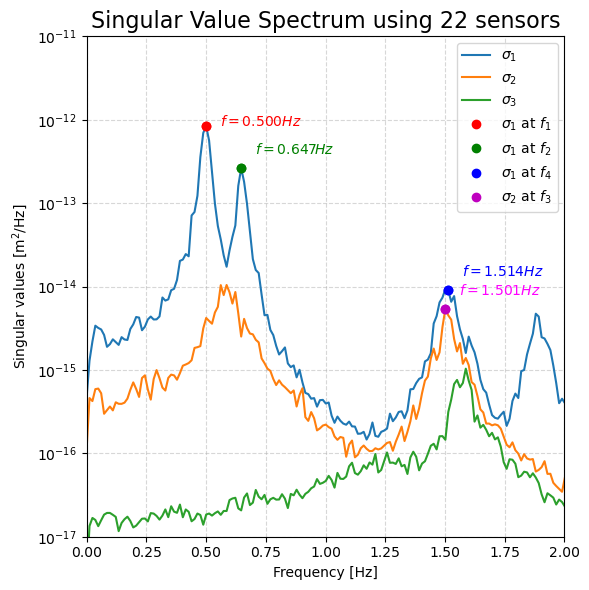

In [30]:
num_modes_to_plot = min(3, m)

plt.figure(figsize=(6, 6))

for i in range(num_modes_to_plot):
    plt.plot(f, Svals[:, i], label=f'$\\sigma_{{{i+1}}}$')

plt.xlim(0, 2)
plt.yscale('log')

plt.xlabel("Frequency [Hz]")
plt.ylabel("Singular values [m$^2$/Hz]")
plt.title("Singular Value Spectrum using 22 sensors", fontsize=16)

plt.plot(f[41], Svals[41, 0], 'ro', label='$\sigma_1$ at $f_1$')
plt.plot(f[53], Svals[53, 0], 'go', label='$\sigma_1$ at $f_2$')
plt.plot(f[124], Svals[124, 0], 'bo', label='$\sigma_1$ at $f_4$')
plt.plot(f[123], Svals[123, 1], 'mo', label='$\sigma_2$ at $f_3$')
ax = plt.gca()

ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_minor_locator(mticker.NullLocator())

plt.plot(f[41], Svals[41, 0], 'ro')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[41]), xy=(f[41], Svals[41, 0]),
             xytext=(10, 0), textcoords='offset points',
             color='red')

plt.plot(f[53], Svals[53, 0], 'go')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[53]), xy=(f[53], Svals[53, 0]),
             xytext=(10, 10), textcoords='offset points',
             color='green')

plt.plot(f[124], Svals[124, 0], 'bo')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[124]), xy=(f[124], Svals[124, 0]),
             xytext=(10, 10), textcoords='offset points',
             color='blue')

plt.plot(f[123], Svals[123, 1], 'mo')
plt.annotate(r'$f = {:.3f} Hz$'.format(f[123]), xy=(f[123], Svals[123, 1]),
             xytext=(10, 10), textcoords='offset points',
             color='magenta')

plt.grid(True, which='major', linestyle='--', alpha=0.5)

# Legend outside
plt.legend(loc='upper right')

plt.tight_layout()
plt.ylim(1e-17, 1e-11)
plt.show()



Natural frequency f_1 = 0.4986 Hz -> index 41
Natural frequency f_2 = 0.6478 Hz -> index 53
Natural frequency f_3 = 1.5061 Hz -> index 123
Natural frequency f_4 = 1.5238 Hz -> index 125
66
4


c:\Users\alami\Desktop\MSc-thesis----Minimal-model----Maeslantkering\scripts\FDD.py:118: ComplexWarning:

Casting complex values to real discards the imaginary part



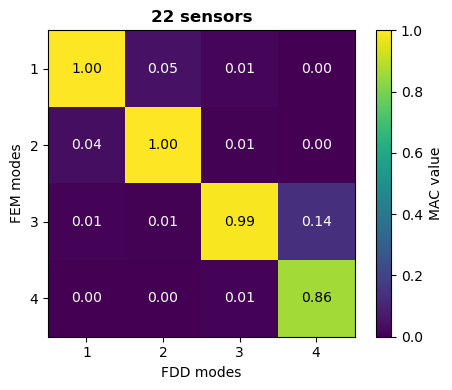

In [31]:
# Obtaining correct index corresponding to natural frequencies in the FDD plot to extract mode shapes.

phi_experiment = []

for i in range(4):
    idx = np.argmin(np.abs(f - frequencies_hz[i]))
    print(f"Natural frequency f_{i+1} = {frequencies_hz[i]:.4f} Hz -> index {idx}")

    mode = U_svd[idx, :, 0]

    # ---- Phase normalization (correct way) ----
    ref = np.argmax(np.abs(mode))
    mode = mode * np.exp(-1j * np.angle(mode[ref]))

    # ---- Normalize magnitude ----
    mode = mode / np.max(np.abs(mode))

    phi_experiment.append(mode)

phi_experiment = np.array(phi_experiment).T   # shape: (channels, modes)

# Reducing the model mode shapes to the DOFS corresponding to the experimental measurements for comparison.
eigvecs_reduced = eigvecs_global[selected_dofs, :4] 


print(len(eigvecs_reduced[:, 0])) 
print(len(phi_experiment[0])) 
fdd.plot_mac(fdd.compute_mac(eigvecs_reduced, phi_experiment), '22 sensors', xlabel='FDD modes', ylabel='FEM modes')
np.save('experimental_eigvectors/phi_experiment_22_sensors.npy', phi_experiment)


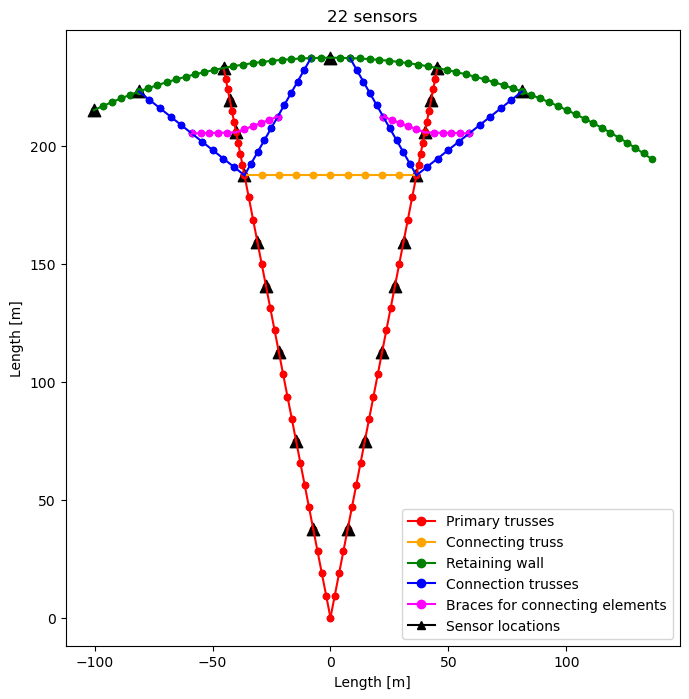

In [32]:
from matplotlib.lines import Line2D

def plot_elements2d(elements):

    fig, ax = plt.subplots(figsize=(8, 8))

    for i, element in enumerate(elements):
        n1, n2, _, _ = element
        x = [n1[0], n2[0]]
        y = [n1[1], n2[1]]

        if i < 60:
            color = 'red'
        elif i < 70:
            color = 'orange'
        elif i < 130:
            color = 'green'
        elif i < 169:
            color = 'blue'
        elif i > 169:
            color = 'magenta'
        # Plot line
        ax.plot(x, y, color=color)

        # Plot nodes
        ax.scatter(*n1[:2], color=color, s=20)
        ax.scatter(*n2[:2], color=color, s=20)
    
    for i, element in enumerate(elements):
        n1, n2, _, _ = element
        x = [n1[0], n2[0]]
        y = [n1[1], n2[1]]

        if i == 130 or i == 140 or i == 150 or i == 160:
            color = 'red'
            ax.scatter(*n1[:2], color=color, s=20)

        elif i == 139 or i == 149 or i == 159 or i == 169:
            color = 'green'
            ax.scatter(*n2[:2], color=color, s=20)
        elif i == 170 or i == 185:
            color = 'red'
            ax.scatter(*n1[:2], color=color, s=20)


    
    # for i, element in enumerate(elements):
        if i == 27 or i == 24 or i == 17 or i == 4 or i == 12 or i == 57 or i == 54 or i == 47 or i == 34 or i == 42 or i == 29 or i == 49 or i == 59 or i == 60 or i == 8 or i == 15 or i == 38 or i == 45 or i == 70 or i == 75 or i == 95 or i == 115:
            color = 'black'
            ax.scatter(*n1[:2], color=color, s=80, marker='^')
  




    # ---- Custom legend: line + ball marker ----
    legend_handles = [
        Line2D([0], [0], color='red', marker='o', markersize=6, label='Primary trusses'),
        Line2D([0], [0], color='orange', marker='o', markersize=6, label='Connecting truss'),
        Line2D([0], [0], color='green', marker='o', markersize=6, label='Retaining wall'),
        Line2D([0], [0], color='blue', marker='o', markersize=6, 
               label='Connection trusses'),
        Line2D([0], [0], color='magenta', marker='o', markersize=6, label='Braces for connecting elements'), 
        Line2D([0], [0], color='black', marker='^', markersize=6, label='Sensor locations')

    ]

    ax.legend(handles=legend_handles, loc='lower right')

    ax.set_xlabel('Length [m]')
    ax.set_ylabel('Length [m]')
    ax.set_aspect('equal')
    ax.set_title('22 sensors')
    plt.show()

plot_elements2d(elements)